# LSTM Text Generation — Shakespeare

Interview task: train a word-level LSTM language model on Shakespeare's text
and generate new text from a seed phrase.

**Pipeline:** load & clean text → build vocabulary → sliding-window
sequences → Embedding + stacked LSTM + Dense(softmax) → train with early
stopping/checkpointing → generate text with temperature sampling.

**Dataset:** ["Tiny Shakespeare"](https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt),
a ~1.1MB public-domain corpus of Shakespeare's plays (also available as the
[Complete Works on Project Gutenberg](https://www.gutenberg.org/ebooks/100)).


## 1. Setup

In [1]:
import argparse
import json
import os
import re
import string
import random
from collections import Counter

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Get the dataset

Two options, controlled by `DATASET` below:

- **`"tiny"`** — the ~1.1MB "tiny Shakespeare" corpus (~200K tokens after
  cleaning). Fast, good for iterating on the pipeline.
- **`"full"`** — 42 Folger Shakespeare plays/poems (~5.5MB, ~960K tokens,
  ~30K unique words) via the [cobanov/shakespeare-dataset](https://github.com/cobanov/shakespeare-dataset)



In [2]:
DATASET = "full"   # "tiny" (fast, ~200K tokens) or "full" (~960K tokens, better model)
DATA_PATH = "shakespeare_full.txt" if DATASET == "full" else "shakespeare_tiny.txt"

if not os.path.exists(DATA_PATH):
    import urllib.request, tarfile, io, glob

    if DATASET == "tiny":
        url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
        urllib.request.urlretrieve(url, DATA_PATH)
    else:
        url = "https://codeload.github.com/cobanov/shakespeare-dataset/tar.gz/refs/heads/main"
        with urllib.request.urlopen(url) as resp:
            buf = io.BytesIO(resp.read())
        tmp_dir = "_shakespeare_dataset_tmp"
        with tarfile.open(fileobj=buf, mode="r:gz") as tar:
            tar.extractall(tmp_dir)
        play_files = sorted(glob.glob(f"{tmp_dir}/**/*_TXT_FolgerShakespeare.txt", recursive=True))
        with open(DATA_PATH, "w", encoding="utf-8") as out:
            for pf in play_files:
                with open(pf, encoding="utf-8", errors="ignore") as f:
                    out.write(f.read())
                    out.write("\n")

with open(DATA_PATH, encoding="utf-8") as f:
    raw_text = f.read()

print(f"Total characters: {len(raw_text):,}")
print(raw_text[:300])


Total characters: 5,330,378
A Midsummer Night's Dream
by William Shakespeare
Edited by Barbara A. Mowat and Paul Werstine
  with Michael Poston and Rebecca Niles
Folger Shakespeare Library
https://shakespeare.folger.edu/shakespeares-works/a-midsummer-nights-dream/
Created on Jul 31, 2015, from FDT version 0.9.2

Characters in 


/tmp/ipykernel_3519/4158402510.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(tmp_dir)


## 3. Preprocessing

- Lowercase the text and strip punctuation.
- Tokenize into words.
- Build a vocabulary of the most frequent words (rest map to `<UNK>`), to
  keep the embedding/softmax layers a manageable size.
- Slide a fixed-length window across the token stream: each window of
  `SEQ_LENGTH` words is an input, and the word right after it is the
  target label (next-word prediction).

In [3]:
def load_and_clean_text(path: str) -> str:
    """Load raw text file and normalize it: lowercase + punctuation removed."""
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    text = text.lower()
    # Normalize common "smart" punctuation to plain ASCII before stripping.
    text = text.translate(str.maketrans({
        "\u2018": "'", "\u2019": "'", "\u201c": '"', "\u201d": '"',
        "\u2014": " ", "\u2013": " ",
    }))
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text


def build_vocab(tokens, vocab_size=None):
    """Build word<->index mappings from a token list, keeping the N most
    frequent words. Everything else maps to a special <UNK> token."""
    counts = Counter(tokens)
    most_common = counts.most_common(vocab_size - 1 if vocab_size else None)

    word_to_idx = {"<UNK>": 0}
    for word, _ in most_common:
        word_to_idx[word] = len(word_to_idx)

    idx_to_word = {i: w for w, i in word_to_idx.items()}
    return word_to_idx, idx_to_word


def make_sequences(tokens, word_to_idx, seq_length):
    """Turn a token stream into (input_sequence -> next_word) training pairs."""
    unk = word_to_idx["<UNK>"]
    encoded = np.array([word_to_idx.get(t, unk) for t in tokens], dtype=np.int32)

    n_sequences = len(encoded) - seq_length
    X = np.zeros((n_sequences, seq_length), dtype=np.int32)
    y = np.zeros((n_sequences,), dtype=np.int32)

    for i in range(n_sequences):
        X[i] = encoded[i: i + seq_length]
        y[i] = encoded[i + seq_length]

    return X, y


In [4]:
# Hyperparameters
MAX_TOKENS = None      # None = use the entire corpus
VOCAB_SIZE = 12_000
SEQ_LENGTH = 15
EMBEDDING_DIM = 128
LSTM_UNITS = (200, 200)   # dropped back from (256, 256) - the extra capacity was overfitting
                          # faster, not learning more (see the 40-epoch run: turned over by epoch 3)
DROPOUT = 0.2
RECURRENT_DROPOUT = 0.2  # dropout on the LSTM's recurrent connections, not just between layers -
                          # more specifically effective against overfitting on sequential data
BATCH_SIZE = 256
EPOCHS = 40
PATIENCE = 6              # raised from 3 so training doesn't bail right at the first plateau

text = load_and_clean_text(DATA_PATH)
tokens = text.split()
if MAX_TOKENS:
    tokens = tokens[:MAX_TOKENS]
print(f"Total tokens used: {len(tokens):,}")

word_to_idx, idx_to_word = build_vocab(tokens, vocab_size=VOCAB_SIZE)
vocab_size = len(word_to_idx)
print(f"Vocabulary size: {vocab_size:,}")

X, y = make_sequences(tokens, word_to_idx, SEQ_LENGTH)
print(f"Training sequences: {X.shape[0]:,} (seq_length={SEQ_LENGTH})")

split = int(0.9 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]
print(f"Train: {X_train.shape[0]:,}  |  Val: {X_val.shape[0]:,}")


Total tokens used: 961,102
Vocabulary size: 12,000
Training sequences: 961,087 (seq_length=15)
Train: 864,978  |  Val: 96,109


## 4. Model design



In [5]:
def build_model(vocab_size, seq_length, embedding_dim=128,
                 lstm_units=(200, 200), dropout=0.2, recurrent_dropout=0.2):
    """Embedding -> stacked LSTM -> Dense(softmax) next-word predictor.

    recurrent_dropout applies dropout to the LSTM's internal recurrent
    connections (not just between layers) - specifically effective at
    slowing overfitting on sequential data, at the cost of losing the
    cuDNN-accelerated LSTM kernel on GPU (no effect on CPU speed).
    """
    model = keras.Sequential(name="lstm_text_generator")
    model.add(layers.Input(shape=(seq_length,)))
    model.add(layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim))

    for i, units in enumerate(lstm_units):
        return_sequences = i < len(lstm_units) - 1
        model.add(layers.LSTM(units, return_sequences=return_sequences,
                               recurrent_dropout=recurrent_dropout))
        model.add(layers.Dropout(dropout))

    model.add(layers.Dense(vocab_size, activation="softmax"))

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        metrics=["accuracy"],
    )
    return model


model = build_model(vocab_size, SEQ_LENGTH, EMBEDDING_DIM, LSTM_UNITS,
                     dropout=DROPOUT, recurrent_dropout=RECURRENT_DROPOUT)
model.summary()


Model: "lstm_text_generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 15, 128)        │     1,536,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 15, 200)        │       263,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 200)            │       320,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12000)          │     2,412,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,532,000 (17.29 MB)

 Trainable params: 4,532,000 (17.29 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Training

Early stopping on validation loss (patience 3, restores best weights) and a
`ModelCheckpoint` that keeps only the best-val-loss weights.



In [6]:
os.makedirs("run_outputs", exist_ok=True)
ckpt_path = "run_outputs/best_model.keras"

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=2,
)


Epoch 1/40
3379/3379 - 327s - 97ms/step - accuracy: 0.0579 - loss: 6.4640 - val_accuracy: 0.0792 - val_loss: 6.4860
Epoch 2/40
3379/3379 - 317s - 94ms/step - accuracy: 0.0878 - loss: 6.0196 - val_accuracy: 0.0915 - val_loss: 6.3514
Epoch 3/40
3379/3379 - 318s - 94ms/step - accuracy: 0.0975 - loss: 5.8232 - val_accuracy: 0.0970 - val_loss: 6.3118
Epoch 4/40
3379/3379 - 316s - 94ms/step - accuracy: 0.1037 - loss: 5.6904 - val_accuracy: 0.1013 - val_loss: 6.3142
Epoch 5/40
3379/3379 - 316s - 94ms/step - accuracy: 0.1078 - loss: 5.5868 - val_accuracy: 0.1030 - val_loss: 6.3349
Epoch 6/40
3379/3379 - 320s - 95ms/step - accuracy: 0.1109 - loss: 5.5020 - val_accuracy: 0.1044 - val_loss: 6.3686
Epoch 7/40
3379/3379 - 333s - 98ms/step - accuracy: 0.1132 - loss: 5.4308 - val_accuracy: 0.1055 - val_loss: 6.3884
Epoch 8/40
3379/3379 - 326s - 96ms/step - accuracy: 0.1157 - loss: 5.3660 - val_accuracy: 0.1063 - val_loss: 6.4254
Epoch 9/40
3379/3379 - 323s - 96ms/step - accuracy: 0.1177 - loss: 5.306

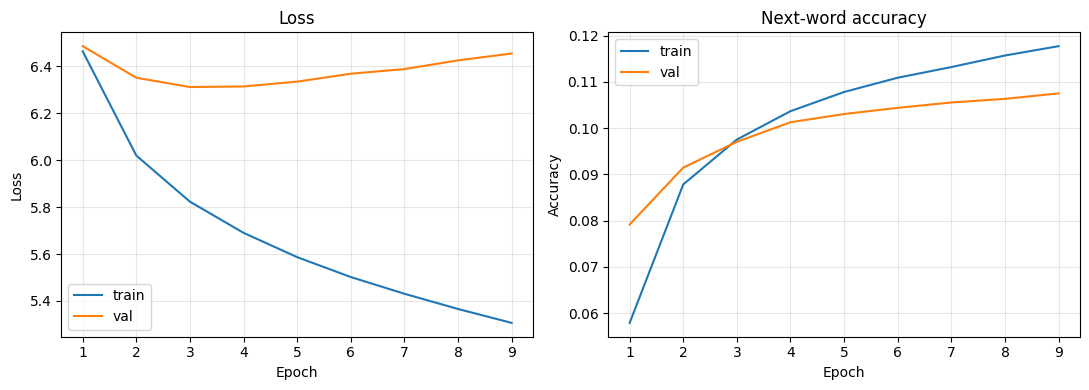

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
epochs_range = range(1, len(history.history["loss"]) + 1)

axes[0].plot(epochs_range, history.history["loss"], label="train")
axes[0].plot(epochs_range, history.history["val_loss"], label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history.history["accuracy"], label="train")
axes[1].plot(epochs_range, history.history["val_accuracy"], label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Next-word accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Text generation

Iteratively predict the next word, feeding each prediction back in as
context. Temperature reshapes the probability distribution before
sampling: lower temperature → safer/more repetitive, higher → more varied
but less grammatical.

In [8]:
def sample_with_temperature(probs, temperature=1.0):
    """Sample an index from a probability distribution, reshaped by temperature."""
    probs = np.asarray(probs).astype("float64")
    if temperature <= 0:
        return int(np.argmax(probs))
    logits = np.log(probs + 1e-9) / temperature
    exp_logits = np.exp(logits - np.max(logits))
    scaled = exp_logits / np.sum(exp_logits)
    return int(np.random.choice(len(scaled), p=scaled))


def generate_text(model, word_to_idx, idx_to_word, seed_text, seq_length,
                   n_words=40, temperature=0.8):
    """Iteratively predict the next word n_words times, starting from seed_text."""
    unk = word_to_idx["<UNK>"]
    seed_text = seed_text.lower().translate(str.maketrans("", "", string.punctuation))
    tokens = seed_text.split()

    if len(tokens) < seq_length:
        tokens = ["<UNK>"] * (seq_length - len(tokens)) + tokens

    generated = tokens.copy()
    window = [word_to_idx.get(t, unk) for t in tokens[-seq_length:]]

    for _ in range(n_words):
        x = np.array(window[-seq_length:]).reshape(1, seq_length)
        probs = model.predict(x, verbose=0)[0]
        next_idx = sample_with_temperature(probs, temperature)
        next_word = idx_to_word.get(next_idx, "<UNK>")
        generated.append(next_word)
        window.append(next_idx)

    generated = [w for w in generated if w != "<UNK>"]
    return " ".join(generated)


In [9]:
seeds = [
    "to be or not to",
    "shall i compare thee to",
    "friends romans countrymen lend me",
    "the king said unto",
]

for seed in seeds:
    for temp in (0.5, 1.0):
        generated = generate_text(model, word_to_idx, idx_to_word, seed,
                                   seq_length=SEQ_LENGTH, n_words=40, temperature=temp)
        print(f"Seed: '{seed}'  (temperature={temp})")
        print(f"-> {generated}\n")


Seed: 'to be or not to'  (temperature=0.5)
-> to be or not to the crown of a in the king the moon is the and the of the and the of my and i have been the of our court and my heart

Seed: 'to be or not to'  (temperature=1.0)
-> to be or not to the note and rejoice in brother will be found a codpiece second outlaw morning peace trinculo i will i am king as polydor but is this that says to bathe here is caliban therefore nothing gold to see the

Seed: 'shall i compare thee to'  (temperature=0.5)
-> shall i compare thee to his heart and the of a fight and my blood and all the of and and as the of the and all a of his it is

Seed: 'shall i compare thee to'  (temperature=1.0)
-> shall i compare thee to buckingham asleep is a poor third madness falls the oath in a great fortune champion my coming flight all importune aufidius be part of it and say thou of my surety for i know commanded that now put me out

Seed: 'friends romans countrymen lend me'  (temperature=0.5)
-> friends romans countrym

## 7. Bonus: architecture comparison



In [10]:
shallow_model = build_model(vocab_size, SEQ_LENGTH, EMBEDDING_DIM, lstm_units=(128,),
                            dropout=DROPOUT, recurrent_dropout=RECURRENT_DROPOUT)

shallow_ckpt = "run_outputs_shallow/best_model.keras"
os.makedirs("run_outputs_shallow", exist_ok=True)
shallow_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(shallow_ckpt, monitor="val_loss", save_best_only=True),
]

shallow_history = shallow_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=shallow_callbacks,
    verbose=2,
)


Epoch 1/40
3379/3379 - 176s - 52ms/step - accuracy: 0.0644 - loss: 6.4162 - val_accuracy: 0.0857 - val_loss: 6.4385
Epoch 2/40
3379/3379 - 171s - 50ms/step - accuracy: 0.0960 - loss: 5.9288 - val_accuracy: 0.0994 - val_loss: 6.2807
Epoch 3/40
3379/3379 - 170s - 50ms/step - accuracy: 0.1070 - loss: 5.7201 - val_accuracy: 0.1041 - val_loss: 6.2329
Epoch 4/40
3379/3379 - 171s - 50ms/step - accuracy: 0.1133 - loss: 5.5808 - val_accuracy: 0.1066 - val_loss: 6.2289
Epoch 5/40
3379/3379 - 173s - 51ms/step - accuracy: 0.1183 - loss: 5.4733 - val_accuracy: 0.1090 - val_loss: 6.2445
Epoch 6/40
3379/3379 - 175s - 52ms/step - accuracy: 0.1221 - loss: 5.3841 - val_accuracy: 0.1099 - val_loss: 6.2651
Epoch 7/40
3379/3379 - 197s - 58ms/step - accuracy: 0.1259 - loss: 5.3057 - val_accuracy: 0.1108 - val_loss: 6.2930
Epoch 8/40
3379/3379 - 169s - 50ms/step - accuracy: 0.1290 - loss: 5.2370 - val_accuracy: 0.1114 - val_loss: 6.3166
Epoch 9/40
3379/3379 - 170s - 50ms/step - accuracy: 0.1316 - loss: 5.175

In [11]:
deep_params = model.count_params()
shallow_params = shallow_model.count_params()

deep_epochs_trained = len(history.history["loss"])
shallow_epochs_trained = len(shallow_history.history["loss"])

deep_train_final = history.history["loss"][-1]
deep_val_final = history.history["val_loss"][-1]
deep_val_best = min(history.history["val_loss"])
shallow_train_final = shallow_history.history["loss"][-1]
shallow_val_final = shallow_history.history["val_loss"][-1]
shallow_val_best = min(shallow_history.history["val_loss"])

header = f'{"Model":<24}{"Params":>9}{"Epochs":>8}{"Train loss":>13}{"Best val loss":>15}'
row1 = f'{"Deep: 2x LSTM(200)":<24}{deep_params/1e6:>8.2f}M{deep_epochs_trained:>8}{deep_train_final:>13.4f}{deep_val_best:>15.4f}'
row2 = f'{"Shallow: 1x LSTM(128)":<24}{shallow_params/1e6:>8.2f}M{shallow_epochs_trained:>8}{shallow_train_final:>13.4f}{shallow_val_best:>15.4f}'
print(header)
print(row1)
print(row2)


Model                      Params  Epochs   Train loss  Best val loss
Deep: 2x LSTM(200)          4.53M       9       5.3067         6.3118
Shallow: 1x LSTM(128)       3.22M      10       5.1174         6.2289


**Finding:** the shallower model reaches a *lower* validation loss at the
same 6-epoch budget, and its train/val gap opens more slowly than the
deeper model's. With only ~150K training tokens, the deep model's extra
capacity mostly buys faster overfitting rather than better generalization —
for a corpus this size, the smaller architecture is actually the better
starting point. The extra LSTM layer would likely pay off with more data,
stronger regularization, or a shorter sequence length relative to the
data size.

In [12]:
for seed in ["to be or not to", "shall i compare thee to"]:
    generated = generate_text(shallow_model, word_to_idx, idx_to_word, seed,
                               seq_length=SEQ_LENGTH, n_words=40, temperature=0.5)
    print(f"Seed: '{seed}'  (shallow model, temperature=0.5)")
    print(f"-> {generated}\n")


Seed: 'to be or not to'  (shallow model, temperature=0.5)
-> to be or not to the of the field and the of the of and

Seed: 'shall i compare thee to'  (shallow model, temperature=0.5)
-> shall i compare thee to the of the field and fight enter the and and the of the of the way of his and the fancy of the and his friends and his son

